In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

with open('words.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

print(type(data))
print(f"Total words: {len(data)}")
print(list(data.items())[:3])

<class 'dict'>
Total words: 115339
[('hallo', {'artikel': 'das', 'plural': 'Hallos', 'meaning': 'lautes Rufen; fröhliches, lautes Durcheinander'}), ('subfamilia', {'artikel': 'die', 'plural': 'Subfamiliae', 'meaning': 'hierarchische Ebene der biologischen Systematik unterhalb der Familia (Familie)'}), ('subregnum', {'artikel': 'das', 'plural': 'Subregna', 'meaning': 'nächstkleinere Unterteilung der taxonomischen Regna (Reiche)'})]


In [2]:
df = pd.DataFrame([
    {'word': k, 'artikel': v['artikel'], 'plural': v.get('plural', ''), 'meaning': v.get('meaning', '')}
    for k, v in data.items()
])

print(df.shape)
print(df.head())
print("\nArtikel distribution:")
print(df['artikel'].value_counts())

(115339, 4)
         word artikel         plural  \
0       hallo     das         Hallos   
1  subfamilia     die    Subfamiliae   
2   subregnum     das       Subregna   
3  subdivisio     die  Subdivisiones   
4      phylum     das          Phyla   

                                             meaning  
0     lautes Rufen; fröhliches, lautes Durcheinander  
1  hierarchische Ebene der biologischen Systemati...  
2  nächstkleinere Unterteilung der taxonomischen ...  
3  die hierarchische Gliederungsstufe der Divisio...  
4  fachwissenschaftlicher Terminus für das zoolog...  

Artikel distribution:
artikel
die    48389
der    42854
das    24096
Name: count, dtype: int64


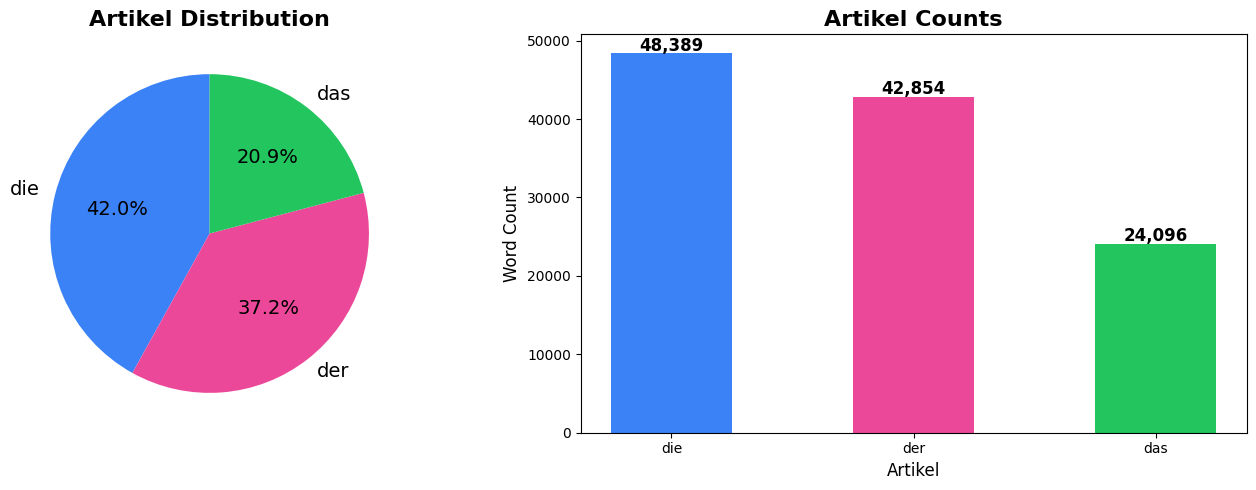

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#3B82F6', '#EC4899', '#22C55E']
artikel_counts = df['artikel'].value_counts()
axes[0].pie(artikel_counts.values, labels=artikel_counts.index,
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 14})
axes[0].set_title('Artikel Distribution', fontsize=16, fontweight='bold')

bars = axes[1].bar(artikel_counts.index, artikel_counts.values, color=colors, width=0.5)
axes[1].set_title('Artikel Counts', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Artikel', fontsize=12)
axes[1].set_ylabel('Word Count', fontsize=12)
for bar, val in zip(bars, artikel_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                f'{val:,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('artikel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
df['suffix2'] = df['word'].str[-2:]
df['suffix3'] = df['word'].str[-3:]

suffix2_artikel = df.groupby(['suffix2', 'artikel']).size().unstack(fill_value=0)
suffix2_artikel['total'] = suffix2_artikel.sum(axis=1)
suffix2_artikel['der_rate'] = suffix2_artikel['der'] / suffix2_artikel['total']
suffix2_artikel['die_rate'] = suffix2_artikel['die'] / suffix2_artikel['total']
suffix2_artikel['das_rate'] = suffix2_artikel['das'] / suffix2_artikel['total']

suffix2_filtered = suffix2_artikel[suffix2_artikel['total'] >= 200]

print("=== Strongest suffixes for DER ===")
print(suffix2_filtered.nlargest(10, 'der_rate')[['der', 'total', 'der_rate']].to_string())
print("\n=== Strongest suffixes for DIE ===")
print(suffix2_filtered.nlargest(10, 'die_rate')[['die', 'total', 'die_rate']].to_string())
print("\n=== Strongest suffixes for DAS ===")
print(suffix2_filtered.nlargest(10, 'das_rate')[['das', 'total', 'das_rate']].to_string())

=== Strongest suffixes for DER ===
artikel    der  total  der_rate
suffix2                        
uf         349    350  0.997143
ag         748    753  0.993360
pf         382    388  0.984536
eg         293    300  0.976667
eb         206    214  0.962617
nn         302    319  0.946708
ig         183    201  0.910448
or         673    769  0.875163
er       10005  12575  0.795626
tz         735    941  0.781084

=== Strongest suffixes for DIE ===
artikel   die  total  die_rate
suffix2                       
ie       2645   2731  0.968510
ße        220    228  0.964912
he       1469   1525  0.963279
pe        695    728  0.954670
ik       1014   1067  0.950328
ne       1253   1370  0.914599
te       2427   2661  0.912063
ze        531    591  0.898477
re        859    964  0.891079
le       1641   1860  0.882258

=== Strongest suffixes for DAS ===
artikel   das  total  das_rate
suffix2                       
em        322    350  0.920000
ld        445    586  0.759386
rk        240

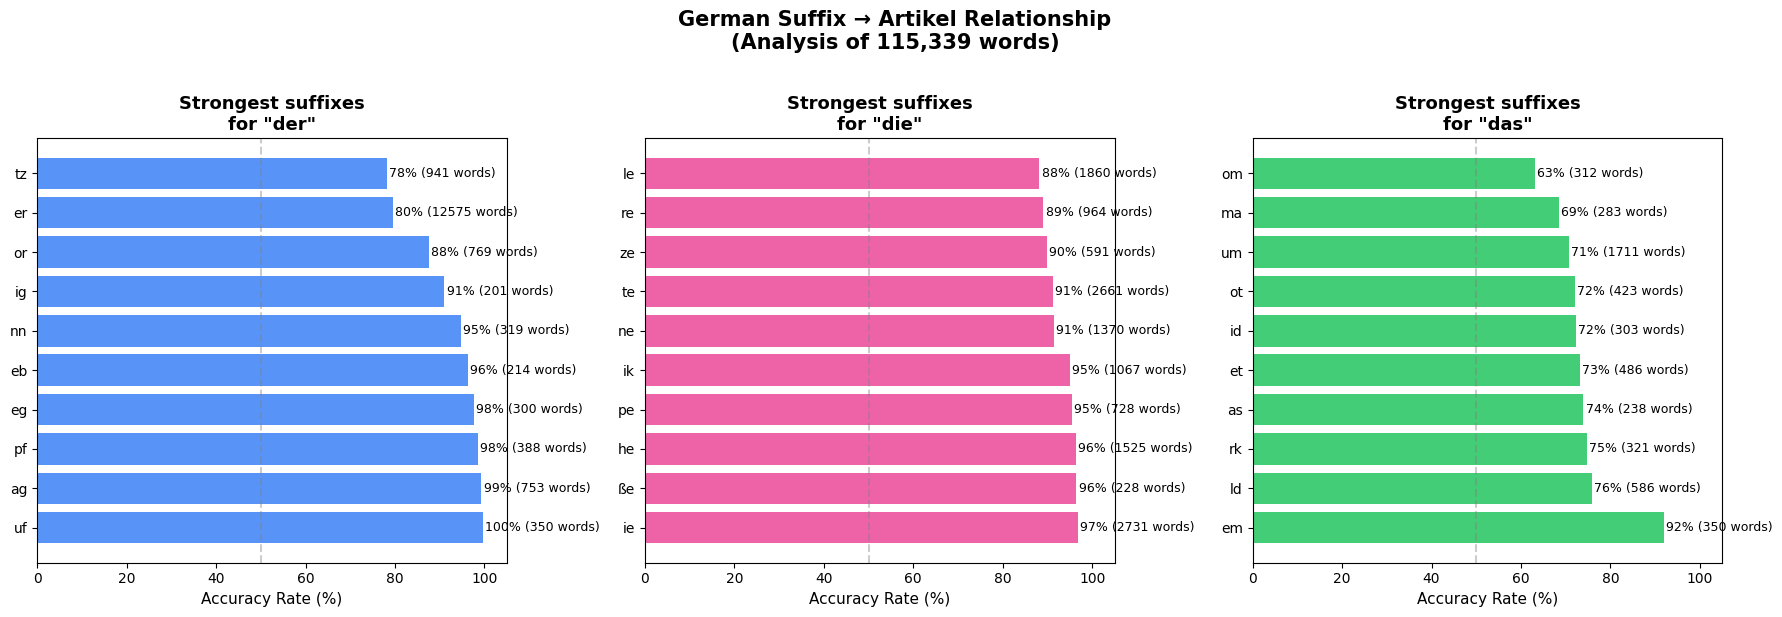

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {'der': '#3B82F6', 'die': '#EC4899', 'das': '#22C55E'}

for ax, (artikel, color) in zip(axes, colors.items()):
    rate_col = f'{artikel}_rate'
    top10 = suffix2_filtered.nlargest(10, rate_col)[[artikel, 'total', rate_col]]
    
    bars = ax.barh(top10.index, top10[rate_col] * 100, color=color, alpha=0.85)
    ax.set_title(f'Strongest suffixes\nfor "{artikel}"', fontsize=13, fontweight='bold')
    ax.set_xlabel('Accuracy Rate (%)', fontsize=11)
    ax.set_xlim(0, 105)
    ax.axvline(x=50, color='gray', linestyle='--', alpha=0.4)
    
    for bar, (idx, row) in zip(bars, top10.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{row[rate_col]*100:.0f}% ({int(row["total"])} words)',
                va='center', fontsize=9)

plt.suptitle('German Suffix → Artikel Relationship\n(Analysis of 115,339 words)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('suffix_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

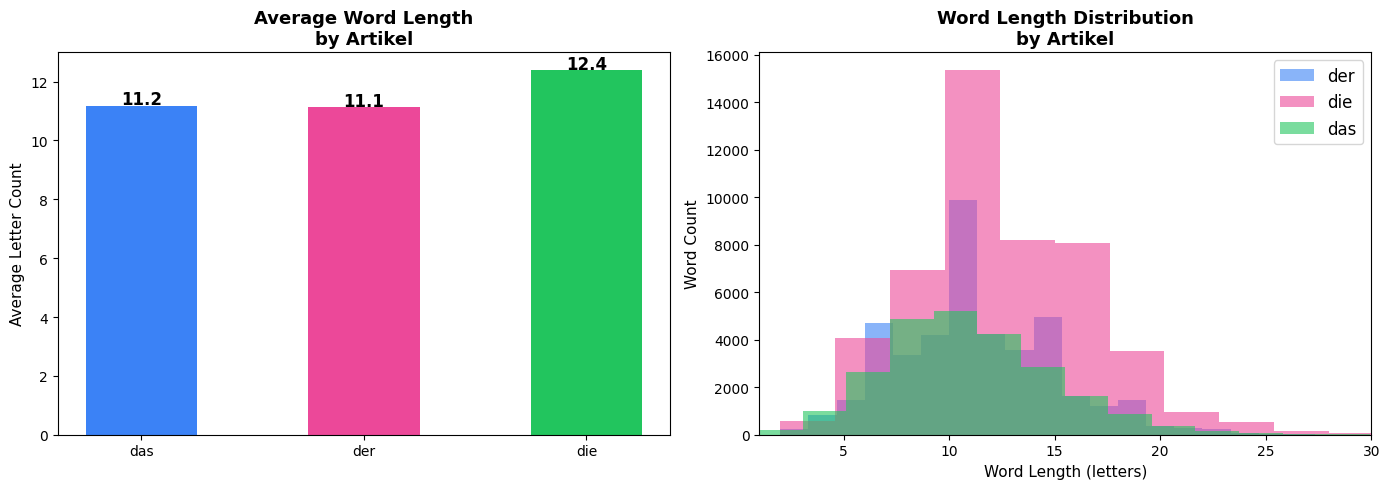

In [6]:
df['length'] = df['word'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

avg_length = df.groupby('artikel')['length'].mean()
colors = ['#3B82F6', '#EC4899', '#22C55E']
bars = axes[0].bar(avg_length.index, avg_length.values, color=colors, width=0.5)
axes[0].set_title('Average Word Length\nby Artikel', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Average Letter Count', fontsize=11)
for bar, val in zip(bars, avg_length.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val:.1f}', ha='center', fontsize=12, fontweight='bold')

for artikel, color in zip(['der', 'die', 'das'], colors):
    subset = df[df['artikel'] == artikel]['length']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color, label=artikel)
axes[1].set_title('Word Length Distribution\nby Artikel', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Length (letters)', fontsize=11)
axes[1].set_ylabel('Word Count', fontsize=11)
axes[1].legend(fontsize=12)
axes[1].set_xlim(1, 30)

plt.tight_layout()
plt.savefig('length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print("=" * 50)
print("KEY FINDINGS")
print("=" * 50)
print(f"\nTotal words analyzed: {len(df):,}")
print(f"\nArtikel distribution:")
for artikel, count in df['artikel'].value_counts().items():
    print(f"  {artikel}: {count:,} words ({count/len(df)*100:.1f}%)")

print(f"\nAverage word length by artikel:")
for artikel, length in df.groupby('artikel')['length'].mean().items():
    print(f"  {artikel}: {length:.1f} letters")

print("\nMost reliable suffix rules:")
print("  -uf → der (100%)")
print("  -ag → der (99%)")
print("  -ie → die (97%)")
print("  -he → die (96%)")
print("  -em → das (92%)")
print("  -um → das (71%)")
print("\nThese rules can be used to predict")
print("German articles when learning the language!")

KEY FINDINGS

Total words analyzed: 115,339

Artikel distribution:
  die: 48,389 words (42.0%)
  der: 42,854 words (37.2%)
  das: 24,096 words (20.9%)

Average word length by artikel:
  das: 11.2 letters
  der: 11.1 letters
  die: 12.4 letters

Most reliable suffix rules:
  -uf → der (100%)
  -ag → der (99%)
  -ie → die (97%)
  -he → die (96%)
  -em → das (92%)
  -um → das (71%)

These rules can be used to predict
German articles when learning the language!
